# Gaussian Processes Summer School

## Part 5: Amortized variational GPLVMs on MNIST

In Parts 1--4 the GP inputs were observed. Here they are learned: every MNIST image
$\mathbf y_n\in\mathbb R^{784}$ receives a low-dimensional latent coordinate
$\mathbf x_n\in\mathbb R^Q$. We first use an RBF kernel and then replace its Gaussian
spectrum by the learnable three-Gaussian mixture introduced in Part 2.

### Learning goals

1. Understand dimensionality reduction as inference in a Gaussian process latent variable model (GPLVM).
2. Amortize the variational distribution $q_\phi(X\mid Y)$ with a neural network.
3. Train with a Monte Carlo estimate of the ELBO while keeping $q(W)=p_\theta(W)$.
4. Compare an RBF spectral prior with a learned symmetric mixture of three Gaussians.

A reproducible balanced subset of 1,000 MNIST images (100 per digit) is used in one full-batch
ELBO. With $L=200$ random Fourier features, the determinant lemma and Woodbury identity reduce GP
inference to $L\times L$ linear algebra: the $N\times N$ covariance is never constructed. This is
not a sparse or inducing-point GPLVM.

## 1. Model and variational objective

Let $Y=[\mathbf y_1^\top,\ldots,\mathbf y_N^\top]^\top\in\mathbb R^{N\times D}$,
where $D=784$, and let $X\in\mathbb R^{N\times Q}$ with $Q=10$. A GPLVM reverses the
usual regression roles:

$$\mathbf x_n\sim\mathcal N(0,I),\qquad
f_d(\cdot)\sim\mathcal{GP}(0,k_\theta),\qquad
y_{nd}=f_d(\mathbf x_n)+\epsilon_{nd}.$$

The $D$ pixel functions are conditionally independent but share the same latent inputs and
kernel. Consequently, $p(Y\mid X)=\prod_{d=1}^D\mathcal N(\mathbf y_{:d};0,K_X+\sigma^2I)$.

Unlike the original GPLVM, we do not store one free variational mean and variance per training
example. A shared encoder reads an **observed image** and outputs

$$q_\phi(\mathbf x_n\mid\mathbf y_n)
=\mathcal N\!\left(\boldsymbol\mu_\phi(\mathbf y_n),
\operatorname{diag}(\boldsymbol\sigma_\phi^2(\mathbf y_n))\right).$$

This is amortized inference: the same network can embed a previously unseen image. Notice that
the network input is $\mathbf y_n$, not the unknown $\mathbf x_n$.

### Random Fourier representation and $q(W)=p(W)$

For a stationary kernel, Bochner's theorem gives

$$k_\theta(\mathbf x,\mathbf x')
=\mathbb E_{p_\theta(\mathbf w)}
\left[\cos\big(\mathbf w^\top(\mathbf x-\mathbf x')\big)\right].$$

With random phases $b_l\sim\mathrm{Uniform}(0,2\pi)$, we use

$$\phi_l(\mathbf x)=\sqrt{\frac{2}{L}}
\cos(\mathbf w_l^\top\mathbf x+b_l),\qquad
K_X\approx\sigma_f^2\Phi(X)\Phi(X)^\top.$$

We choose $q(W)=p_\theta(W)$ and draw fresh reparameterized frequencies during training. Thus
$\mathrm{KL}[q(W)\|p(W)]=0$. The ELBO is

$$\mathcal L=
\underbrace{\mathbb E_{q_\phi(X\mid Y)p_\theta(W)}
[\log p(Y\mid X,W)]}_{\text{reconstruction term}}
-\mathrm{KL}[q_\phi(X\mid Y)\|p(X)].$$

We estimate the expectation with one reparameterized draw
$X=\mu_\phi(Y)+\sigma_\phi(Y)\odot\varepsilon$ and one draw $W\sim p_\theta(W)$ per optimization
step. Learning $\theta$ is empirical Bayes: gradients pass through samples from $p_\theta(W)$.
Tying $q(W)$ to the prior is simple and cheap, but it does **not** learn a data-adapted posterior
over individual frequencies.

### Full-batch likelihood without an $N\times N$ covariance

Write $F=\sqrt{\sigma_f^2}\,\Phi_W(X)$ and $C=FF^\top+\sigma^2I_N$. For each of the
$D=784$ GP outputs, the marginal covariance is $C$. Therefore, the reconstruction term for a
particular Monte Carlo draw of $(X,W)$ is

$$\log p(Y\mid X,W)=-\frac12\left[
D\log|C|+\operatorname{tr}(Y^\top C^{-1}Y)+ND\log(2\pi)
\right].$$

Thus $F$ and $C$ appear inside the ELBO through both parts of the GP reconstruction score:
$\operatorname{tr}(Y^\top C^{-1}Y)$ measures covariance-weighted data fit, whereas
$D\log|C|$ penalizes overly flexible covariance structure. This is a probabilistic reconstruction
term, not an ordinary pixelwise mean-squared error.

We evaluate both terms efficiently through

$$\log|C|=N\log\sigma^2+
\log\left|I_L+\frac{F^\top F}{\sigma^2}\right|,$$

and

$$C^{-1}=\frac1{\sigma^2}I_N-
\frac1{\sigma^4}F\left(I_L+\frac{F^\top F}{\sigma^2}\right)^{-1}F^\top.$$

Consequently, the implementation stores $F$ ($N\times L$), $F^\top F$ ($L\times L$), and
$F^\top Y$ ($L\times784$), then performs only an $L\times L$ Cholesky decomposition. There are
no explicit random-feature regression weights: they have been analytically marginalized.

In [80]:
import copy
import gzip
import random
import struct
import urllib.request
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from train_amortized_gplvm import (
    AmortizedRFFGPLVM,
    RBFSpectralPrior,
    ThreeGaussianSpectralPrior,
    VariationalGaussianSpectralPosterior,
    latent_means,
    posterior_mean_images,
    train_model,
)

SEED = 52
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [105]:
# Shared configuration for every GPLVM variant in this notebook.
LATENT_DIM = 10
NUM_FOURIER_SAMPLES = 500
NUM_EPOCHS = 5000
PRINT_EVERY = 100
N_TSNE_VISUALIZE = 1000

print(
    f"configuration: Q={LATENT_DIM}, L={NUM_FOURIER_SAMPLES}, "
    f"epochs={NUM_EPOCHS}, print_every={PRINT_EVERY}"
)

configuration: Q=10, L=500, epochs=5000, print_every=100


## 2. MNIST data

We select 100 images independently from each digit class, giving $N=1{,}000$. Pixel values are
centered using the balanced subset mean because the GP likelihood has zero mean. Labels determine
only this balanced sampling and are not part of the GPLVM objective. The first run downloads MNIST
to `./data`.

Y shape: (1000, 784) (examples x pixels)


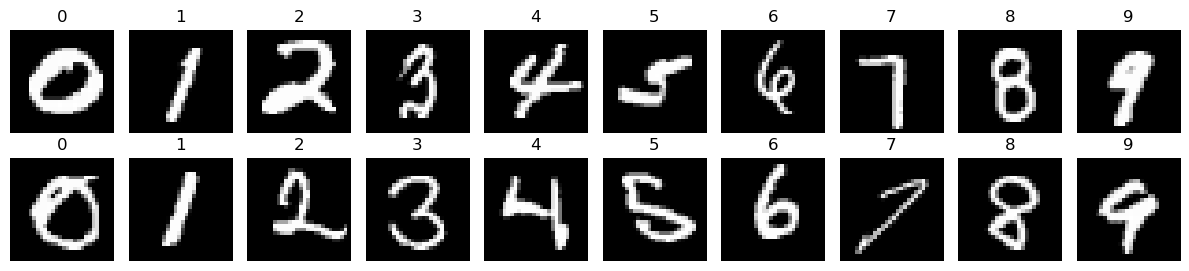

In [106]:
try:
    from torchvision.datasets import MNIST
    from torchvision.transforms import ToTensor
    dataset = MNIST(root="data", train=True, download=True, transform=ToTensor())
    targets = dataset.targets.numpy()
    all_images = dataset.data.reshape(-1, 784).to(torch.float32) / 255.0
except (ImportError, RuntimeError):
    # Standard-library fallback: avoids a scikit-learn/SciPy dependency.
    base_url = "https://storage.googleapis.com/cvdf-datasets/mnist/"
    raw_dir = Path("data/mnist_raw")
    raw_dir.mkdir(parents=True, exist_ok=True)
    files = {"images": "train-images-idx3-ubyte.gz", "labels": "train-labels-idx1-ubyte.gz"}
    for filename in files.values():
        destination = raw_dir / filename
        if not destination.exists():
            print("downloading", filename)
            urllib.request.urlretrieve(base_url + filename, destination)
    with gzip.open(raw_dir / files["images"], "rb") as stream:
        _, count, rows, cols = struct.unpack(">IIII", stream.read(16))
        pixels = np.frombuffer(stream.read(), dtype=np.uint8).reshape(count, rows * cols)
    with gzip.open(raw_dir / files["labels"], "rb") as stream:
        _, count = struct.unpack(">II", stream.read(8))
        targets = np.frombuffer(stream.read(), dtype=np.uint8, count=count).astype(np.int64)
    all_images = torch.as_tensor(pixels.copy(), dtype=torch.float32) / 255.0

rng = np.random.default_rng(SEED)
selected_indices = np.concatenate([
    rng.choice(np.flatnonzero(targets == digit), 100, replace=False)
    for digit in range(10)
])
rng.shuffle(selected_indices)
images_raw = all_images[selected_indices]
labels = targets[selected_indices]
pixel_mean = images_raw.mean(0, keepdim=True)
images = (images_raw - pixel_mean).to(device)
print(f"Y shape: {tuple(images.shape)} (examples x pixels)")

fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for digit, ax_col in enumerate(axes.T):
    examples = np.flatnonzero(labels == digit)[:2]
    for idx, ax in zip(examples, ax_col):
        ax.imshow(images_raw[idx].reshape(28, 28), cmap="gray")
        ax.axis("off")
        ax.set_title(str(digit))
plt.tight_layout()

## 3. Baseline: RBF spectral prior

The RBF kernel has Gaussian spectral density

$$p_\theta(\mathbf w)=\mathcal N\!\left(0,
\operatorname{diag}(\ell_1^{-2},\ldots,\ell_Q^{-2})\right).$$

The ARD lengthscales, output scale, noise, and encoder weights are optimized jointly. The KL is
analytical because both $q_\phi(X\mid Y)$ and $p(X)=\mathcal N(0,I)$ are diagonal Gaussians.
We warm up its coefficient to reduce early posterior collapse.

In [107]:
rbf_model = AmortizedRFFGPLVM(
    observed_dim=images.shape[1], latent_dim=LATENT_DIM,
    num_frequencies=NUM_FOURIER_SAMPLES,
    spectral_prior=RBFSpectralPrior(latent_dim=LATENT_DIM),
).to(device)
rbf_history = train_model(
    rbf_model, images, epochs=NUM_EPOCHS, learning_rate=2e-3,
    beta_warmup_epochs=200, print_every=PRINT_EVERY,
)
print("learned RBF parameters:", rbf_model.spectral_prior.summary())

epoch    1 | loss 0.5900 | log p/pixel -0.5900 | KL(X)/example 0.021 | KL(W) 0.000
epoch  100 | loss -0.0014 | log p/pixel 0.0238 | KL(X)/example 35.131 | KL(W) 0.000
epoch  200 | loss -0.0446 | log p/pixel 0.0894 | KL(X)/example 35.135 | KL(W) 0.000
epoch  300 | loss -0.1039 | log p/pixel 0.1488 | KL(X)/example 35.194 | KL(W) 0.000
epoch  400 | loss -0.1562 | log p/pixel 0.2011 | KL(X)/example 35.240 | KL(W) 0.000
epoch  500 | loss -0.2007 | log p/pixel 0.2457 | KL(X)/example 35.278 | KL(W) 0.000
epoch  600 | loss -0.2389 | log p/pixel 0.2840 | KL(X)/example 35.311 | KL(W) 0.000
epoch  700 | loss -0.2674 | log p/pixel 0.3125 | KL(X)/example 35.351 | KL(W) 0.000
epoch  800 | loss -0.2925 | log p/pixel 0.3378 | KL(X)/example 35.489 | KL(W) 0.000
epoch  900 | loss -0.3123 | log p/pixel 0.3577 | KL(X)/example 35.586 | KL(W) 0.000
epoch 1000 | loss -0.3269 | log p/pixel 0.3724 | KL(X)/example 35.707 | KL(W) 0.000
epoch 1100 | loss -0.3360 | log p/pixel 0.3817 | KL(X)/example 35.819 | KL(W)

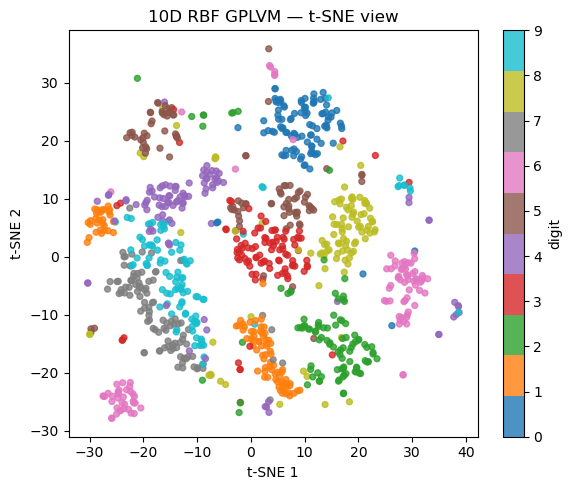

In [108]:
def tsne_projection(z, perplexity=30.0, steps=750, seed=SEED):
    """Exact small-data t-SNE in NumPy/PyTorch, avoiding SciPy."""
    z = np.asarray(z, dtype=np.float32)
    z = (z - z.mean(0)) / (z.std(0) + 1e-6)
    row_norms = np.sum(z * z, axis=1, keepdims=True)
    squared = np.maximum(row_norms + row_norms.T - 2.0 * z @ z.T, 0.0)
    n = len(z)
    conditional = np.zeros((n, n), dtype=np.float64)
    target_entropy = np.log(perplexity)
    for i in range(n):
        mask = np.arange(n) != i
        distances = squared[i, mask]
        low_log_precision, high_log_precision = -20.0, 20.0
        for _ in range(50):
            log_precision = (low_log_precision + high_log_precision) / 2.0
            probabilities = np.exp(-distances * np.exp(log_precision))
            probabilities /= probabilities.sum() + 1e-12
            entropy = -np.sum(probabilities * np.log(probabilities + 1e-12))
            if entropy > target_entropy:
                low_log_precision = log_precision
            else:
                high_log_precision = log_precision
        conditional[i, mask] = probabilities
    joint = (conditional + conditional.T) / (2.0 * n)
    joint = torch.tensor(joint, dtype=torch.float32, device=device).clamp_min(1e-12)

    generator = torch.Generator(device=device).manual_seed(seed)
    projection = torch.nn.Parameter(1e-4 * torch.randn(n, 2, generator=generator, device=device))
    optimizer = torch.optim.Adam([projection], lr=0.5)
    for step in range(steps):
        optimizer.zero_grad(set_to_none=True)
        numerator = 1.0 / (1.0 + torch.cdist(projection, projection).square())
        numerator.fill_diagonal_(0.0)
        q = (numerator / numerator.sum()).clamp_min(1e-12)
        p = joint * (4.0 if step < 150 else 1.0)
        loss = (p * (p.log() - q.log())).sum()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            projection.sub_(projection.mean(0))
    return projection.detach().cpu().numpy()

def plot_embedding(z_2d, labels, title, ax):
    scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap="tab10", s=18, alpha=.8)
    ax.set(title=title, xlabel="t-SNE 1", ylabel="t-SNE 2")
    return scatter

z_rbf = latent_means(rbf_model, images)
visualization_indices = np.arange(len(labels))[:N_TSNE_VISUALIZE]
z_rbf_tsne = tsne_projection(z_rbf[visualization_indices], steps=500, seed=SEED)
fig, ax = plt.subplots(figsize=(6, 5))
plot_embedding(z_rbf_tsne, labels[visualization_indices], "10D RBF GPLVM — t-SNE view", ax)
fig.colorbar(ax.collections[0], ax=ax, ticks=range(10), label="digit")
plt.tight_layout()

## 4. Learned kernel: a symmetric mixture of three Gaussians

As in Part 2, replace the single zero-centered Gaussian spectrum with

$$p_\theta(\mathbf w)=\sum_{q=1}^{3}\rho_q
\left[\tfrac12\mathcal N(\mathbf w;\boldsymbol\mu_q,
\operatorname{diag}(\mathbf s_q^2))+
\tfrac12\mathcal N(\mathbf w;-\boldsymbol\mu_q,
\operatorname{diag}(\mathbf s_q^2))\right].$$

The paired $\pm\boldsymbol\mu_q$ components guarantee a symmetric spectrum and hence a real
stationary kernel. We learn mixture weights, means, and diagonal scales. A straight-through
Gumbel--Softmax sample makes the categorical component differentiable. Again $q(W)=p_\theta(W)$,
so there is no frequency KL term.

For a fairer comparison, the mixture model starts from a copy of the trained RBF encoder and
likelihood parameters; only its spectral family is replaced before fine-tuning.

In [109]:
mixture_model = AmortizedRFFGPLVM(
    observed_dim=images.shape[1], latent_dim=LATENT_DIM,
    num_frequencies=NUM_FOURIER_SAMPLES,
    spectral_prior=ThreeGaussianSpectralPrior(latent_dim=LATENT_DIM),
).to(device)
mixture_model.encoder.load_state_dict(copy.deepcopy(rbf_model.encoder.state_dict()))
with torch.no_grad():
    mixture_model.raw_outputscale.copy_(rbf_model.raw_outputscale)
    mixture_model.raw_noise.copy_(rbf_model.raw_noise)

mixture_history = train_model(
    mixture_model, images, epochs=NUM_EPOCHS, learning_rate=1e-3,
    beta_warmup_epochs=1, print_every=PRINT_EVERY,
)
summary = mixture_model.spectral_prior.summary()
print("weights:", np.round(summary["weights"], 3))
print("means:\n", np.round(summary["means"], 3))
print("scales:\n", np.round(summary["scales"], 3))

epoch    1 | loss -0.2169 | log p/pixel 0.2536 | KL(X)/example 28.761 | KL(W) 0.000
epoch  100 | loss -0.3623 | log p/pixel 0.4020 | KL(X)/example 31.110 | KL(W) 0.000
epoch  200 | loss -0.3628 | log p/pixel 0.4027 | KL(X)/example 31.261 | KL(W) 0.000
epoch  300 | loss -0.3629 | log p/pixel 0.4024 | KL(X)/example 30.970 | KL(W) 0.000
epoch  400 | loss -0.3645 | log p/pixel 0.4039 | KL(X)/example 30.951 | KL(W) 0.000
epoch  500 | loss -0.3656 | log p/pixel 0.4052 | KL(X)/example 31.001 | KL(W) 0.000
epoch  600 | loss -0.3675 | log p/pixel 0.4068 | KL(X)/example 30.813 | KL(W) 0.000
epoch  700 | loss -0.3662 | log p/pixel 0.4048 | KL(X)/example 30.295 | KL(W) 0.000
epoch  800 | loss -0.3656 | log p/pixel 0.4050 | KL(X)/example 30.889 | KL(W) 0.000
epoch  900 | loss -0.3681 | log p/pixel 0.4067 | KL(X)/example 30.266 | KL(W) 0.000
epoch 1000 | loss -0.3690 | log p/pixel 0.4071 | KL(X)/example 29.903 | KL(W) 0.000
epoch 1100 | loss -0.3709 | log p/pixel 0.4100 | KL(X)/example 30.606 | KL(W

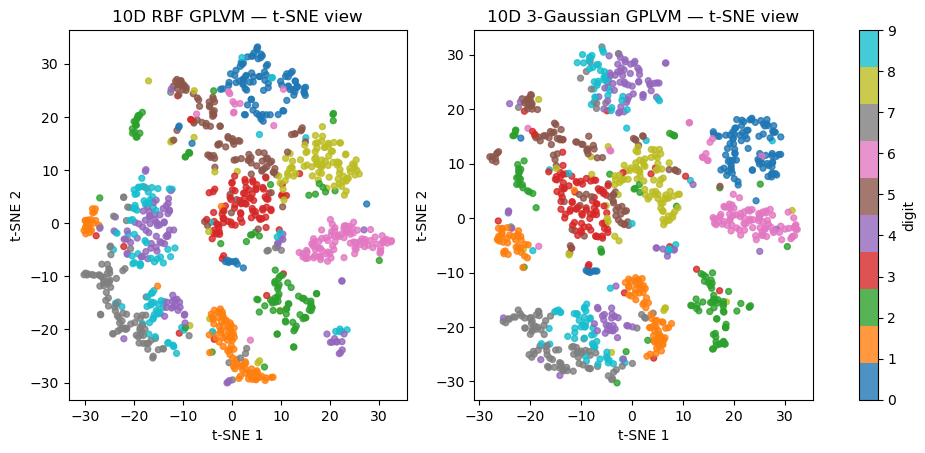

In [86]:
z_mix = latent_means(mixture_model, images)
z_mix_tsne = tsne_projection(z_mix[visualization_indices], steps=500, seed=SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_embedding(z_rbf_tsne, labels[visualization_indices], "10D RBF GPLVM — t-SNE view", axes[0])
plot_embedding(z_mix_tsne, labels[visualization_indices], "10D 3-Gaussian GPLVM — t-SNE view", axes[1])
fig.colorbar(axes[1].collections[0], ax=axes, ticks=range(10), label="digit")
plt.show()

## 5. Generate images from each GPLVM

Generation begins with ten new latent coordinates

$$\mathbf x_*\sim p(\mathbf x)=\mathcal N(0,I_{10}).$$

For each kernel, one coherent spectral draw $W\sim q(W)=p_\theta(W)$ is used to evaluate both
$F=\sqrt{\sigma_f^2}\Phi_W(X)$ and $F_*=\sqrt{\sigma_f^2}\Phi_W(X_*)$. Conditioning on the
training images gives the feature-space posterior

$$M=I_L+\frac{F^\top F}{\sigma^2},\qquad
\mathbb E[f_*\mid Y,X,X_*,W]=F_*M^{-1}\frac{F^\top Y}{\sigma^2}.$$

We display only this conditional posterior mean, add back the training pixel mean, and clip only
for display. We deliberately do not add posterior function noise independently to each pixel.
Both models use the same ten latent draws, so the two $2\times5$ grids compare their learned
generative mappings rather than different latent inputs.

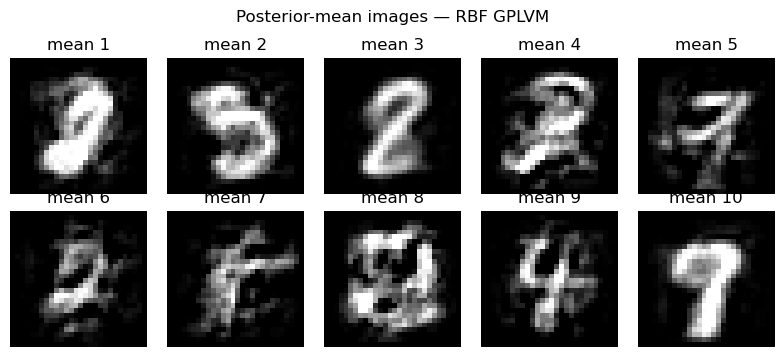

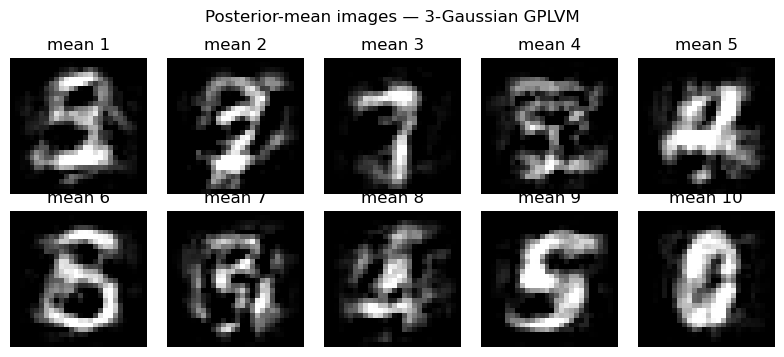

In [110]:
expected_latent_dim, expected_num_features = LATENT_DIM, NUM_FOURIER_SAMPLES
for model_name, model in [("RBF", rbf_model), ("mixture", mixture_model)]:
    if model.latent_dim != expected_latent_dim or model.num_frequencies != expected_num_features:
        raise RuntimeError(
            f"{model_name} model has Q={model.latent_dim}, L={model.num_frequencies}; "
            f"expected Q={expected_latent_dim}, L={expected_num_features}. "
            "Restart the kernel and run all cells from the beginning."
        )

generator = torch.Generator(device=device).manual_seed(SEED + 100)
generation_latents = torch.randn(
    10, expected_latent_dim, generator=generator, device=device
)

rbf_generated = posterior_mean_images(
    rbf_model,
    images,
    torch.as_tensor(z_rbf, dtype=images.dtype, device=device),
    generation_latents,
    seed=SEED + 101,
)
mixture_generated = posterior_mean_images(
    mixture_model,
    images,
    torch.as_tensor(z_mix, dtype=images.dtype, device=device),
    generation_latents,
    seed=SEED + 102,
)

rbf_generated = (rbf_generated + pixel_mean.to(device)).clamp(0, 1).cpu()
mixture_generated = (mixture_generated + pixel_mean.to(device)).clamp(0, 1).cpu()

def plot_generated_grid(generated, title):
    fig, axes = plt.subplots(2, 5, figsize=(8, 3.6))
    for index, ax in enumerate(axes.flat):
        ax.imshow(generated[index].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        ax.set_title(f"mean {index + 1}")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_generated_grid(rbf_generated, "Posterior-mean images — RBF GPLVM")
plot_generated_grid(mixture_generated, "Posterior-mean images — 3-Gaussian GPLVM")

## 6. Quantitative comparison

The GPLVM objective is trained on all 1,000 selected images. The diagnostics below use all of
their **10-dimensional** latent means. The t-SNE coordinates are visualization tools only and
are never used for training or metrics.

RBF {'5-NN accuracy': 0.887, 'silhouette': 0.1}
3-Gaussian mixture {'5-NN accuracy': 0.86, 'silhouette': 0.083}


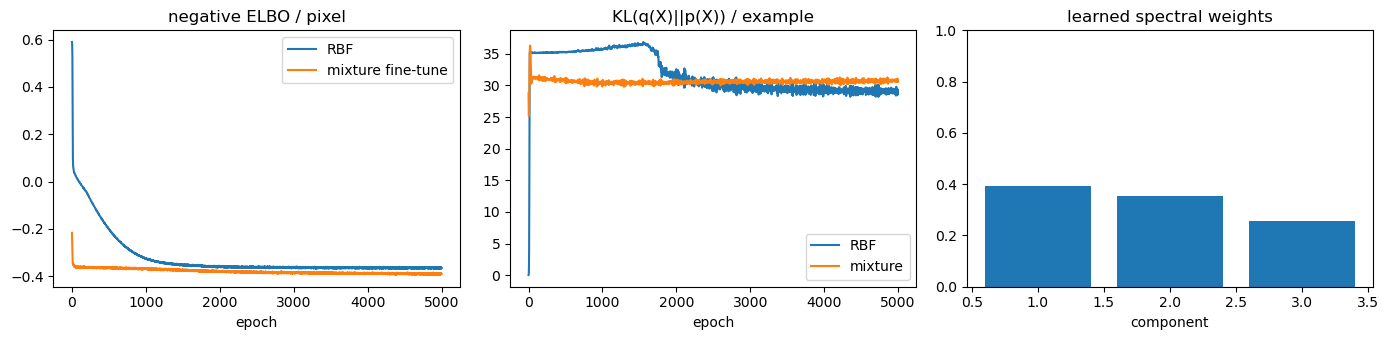

In [111]:
def pairwise_distances(z):
    squared = np.sum(z * z, axis=1, keepdims=True)
    return np.sqrt(np.maximum(squared + squared.T - 2.0 * z @ z.T, 0.0))

def silhouette(z, labels):
    distances = pairwise_distances(z)
    values = []
    for i, label in enumerate(labels):
        same = labels == label
        same[i] = False
        a = distances[i, same].mean() if same.any() else 0.0
        b = min(distances[i, labels == other].mean() for other in np.unique(labels) if other != label)
        values.append((b - a) / max(a, b, 1e-12))
    return float(np.mean(values))

def embedding_metrics(z, labels):
    rng = np.random.default_rng(SEED)
    train_parts, test_parts = [], []
    for digit in np.unique(labels):
        digit_indices = rng.permutation(np.flatnonzero(labels == digit))
        split = int(0.7 * len(digit_indices))
        train_parts.append(digit_indices[:split])
        test_parts.append(digit_indices[split:])
    train_idx, test_idx = np.concatenate(train_parts), np.concatenate(test_parts)
    distances = np.linalg.norm(z[test_idx, None, :] - z[train_idx][None, :, :], axis=-1)
    neighbors = np.argpartition(distances, kth=4, axis=1)[:, :5]
    neighbor_labels = labels[train_idx][neighbors]
    predictions = np.array([np.bincount(row, minlength=10).argmax() for row in neighbor_labels])
    return {
        "5-NN accuracy": float(np.mean(predictions == labels[test_idx])),
        "silhouette": silhouette(z, labels),
    }

for name, z in [("RBF", z_rbf), ("3-Gaussian mixture", z_mix)]:
    metrics = embedding_metrics(z[visualization_indices], labels[visualization_indices])
    print(name, {k: round(v, 3) for k, v in metrics.items()})

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(rbf_history.loss, label="RBF")
axes[0].plot(mixture_history.loss, label="mixture fine-tune")
axes[0].set(title="negative ELBO / pixel", xlabel="epoch"); axes[0].legend()
axes[1].plot(rbf_history.kl_x_per_example, label="RBF")
axes[1].plot(mixture_history.kl_x_per_example, label="mixture")
axes[1].set(title="KL(q(X)||p(X)) / example", xlabel="epoch"); axes[1].legend()
weights = summary["weights"]
axes[2].bar(np.arange(1, 4), weights)
axes[2].set(title="learned spectral weights", xlabel="component", ylim=(0, 1))
plt.tight_layout()

## 7. What the comparison means

- **RBF GPLVM:** one zero-centered Gaussian spectrum imposes a smooth, single-scale geometry in
  latent space. ARD lengthscales can differ across the two latent axes.
- **Three-Gaussian GPLVM:** several spectral bands can express oscillatory and multi-scale
  similarities. Its extra flexibility may improve the embedding, but can also overfit; inspect
  diagnostics and repeat across random seeds.
- **Amortization:** the encoder provides $q_\phi(\mathbf x\mid\mathbf y)$ for new images without
  optimizing a new latent variable from scratch.
- **Ten dimensions versus the plot:** the GPLVM learns and evaluates a 10-dimensional latent
  representation. t-SNE compresses those posterior means to two dimensions only for display;
  distances and apparent clusters in that plot should not be interpreted as the GP latent space.
- **Tied spectral posterior:** $q(W)=p_\theta(W)$ removes a variational KL and avoids storing
  frequency-specific variational parameters. It retains Monte Carlo uncertainty but cannot adapt
  individual frequencies to the dataset independently of the learned prior parameters.
- **Approximation:** both models use exactly $L=200$ RFFs. More frequencies reduce Monte Carlo
  error but increase the $F^\top F$ and $F^\top Y$ costs.
- **Scaling:** the balanced 1,000-image ELBO is evaluated without inducing variables, explicit
  feature weights, mini-batches, or an $N\times N$ covariance. Woodbury reduces the Cholesky
  factorization to $200\times200$.

## 8. Improving the variational approximation with a learned $q(W)$

So far, frequency uncertainty was tied to the kernel prior: $q(W)=p_\theta(W)$. We now perform
an ablation for the RBF model in which each of the $L=200$ frequency vectors has its own diagonal
Gaussian posterior,

$$q_\psi(W)=\prod_{l=1}^{L}\mathcal N
(\mathbf w_l;\mathbf m_l,\operatorname{diag}(\mathbf s_l^2)),$$

while the reference prior is the Gaussian RBF spectrum at the learned RBF lengthscales,

$$p(W)=\prod_{l=1}^{L}\mathcal N
(\mathbf w_l;0,\operatorname{diag}(\boldsymbol\ell^{-2})).$$

The ELBO gains a nonzero spectral regularizer:

$$\mathcal L_{q(W)}=
\mathbb E_{q_\phi(X\mid Y)q_\psi(W)}[\log p(Y\mid X,W)]
-\mathrm{KL}[q_\phi(X\mid Y)\|p(X)]
-\mathrm{KL}[q_\psi(W)\|p(W)].$$

The Gaussian KL is analytic, while the reconstruction expectation still uses one reparameterized
frequency sample. For a controlled comparison, both branches start from the same trained RBF
encoder and likelihood: one continues with tied $q(W)=p(W)$ and the other learns $q_\psi(W)$.
A higher ELBO (which already includes the new KL) indicates a tighter variational fit.

In [115]:
# Two continuations from exactly the same trained RBF state.
tied_w_model = copy.deepcopy(rbf_model)
prior_scale = rbf_model.spectral_prior.lengthscale.detach().reciprocal()
learned_qw_model = AmortizedRFFGPLVM(
    observed_dim=images.shape[1],
    latent_dim=LATENT_DIM,
    num_frequencies=NUM_FOURIER_SAMPLES,
    spectral_prior=VariationalGaussianSpectralPosterior(NUM_FOURIER_SAMPLES, prior_scale),
).to(device)
#learned_qw_model.encoder.load_state_dict(copy.deepcopy(rbf_model.encoder.state_dict()))
with torch.no_grad():
    learned_qw_model.raw_outputscale.copy_(rbf_model.raw_outputscale)
    learned_qw_model.raw_noise.copy_(rbf_model.raw_noise)

tied_w_history = train_model(
    tied_w_model, images, epochs=NUM_EPOCHS, learning_rate=1e-3,
    beta_warmup_epochs=1, print_every=PRINT_EVERY,
)
learned_qw_history = train_model(
    learned_qw_model, images, epochs=NUM_EPOCHS, learning_rate=1e-3,
    beta_warmup_epochs=1, print_every=PRINT_EVERY,
)


epoch    1 | loss -0.3684 | log p/pixel 0.4051 | KL(X)/example 28.761 | KL(W) 0.000
epoch  100 | loss -0.3665 | log p/pixel 0.4032 | KL(X)/example 28.787 | KL(W) 0.000
epoch  200 | loss -0.3679 | log p/pixel 0.4052 | KL(X)/example 29.286 | KL(W) 0.000
epoch  300 | loss -0.3650 | log p/pixel 0.4020 | KL(X)/example 29.029 | KL(W) 0.000
epoch  400 | loss -0.3658 | log p/pixel 0.4026 | KL(X)/example 28.798 | KL(W) 0.000
epoch  500 | loss -0.3669 | log p/pixel 0.4039 | KL(X)/example 29.035 | KL(W) 0.000
epoch  600 | loss -0.3665 | log p/pixel 0.4035 | KL(X)/example 28.975 | KL(W) 0.000
epoch  700 | loss -0.3682 | log p/pixel 0.4051 | KL(X)/example 28.892 | KL(W) 0.000
epoch  800 | loss -0.3687 | log p/pixel 0.4055 | KL(X)/example 28.825 | KL(W) 0.000
epoch  900 | loss -0.3676 | log p/pixel 0.4039 | KL(X)/example 28.514 | KL(W) 0.000
epoch 1000 | loss -0.3651 | log p/pixel 0.4015 | KL(X)/example 28.584 | KL(W) 0.000
epoch 1100 | loss -0.3664 | log p/pixel 0.4034 | KL(X)/example 29.000 | KL(W

KeyboardInterrupt: 

tied q(W)=p(W) {'5-NN accuracy': 0.88, 'silhouette': 0.092}
learned Gaussian q(W) {'5-NN accuracy': 0.863, 'silhouette': 0.097}
mean final ELBO/pixel — q(W)=p(W): 0.36678
mean final ELBO/pixel — learned q(W): 0.36581
ELBO difference (learned − tied): -0.00098
q(W) summary: {'mean_norm': array(4.12880421), 'average_scale': array(0.3630102), 'prior_average_scale': array(0.36987138)}


/tmp/ipykernel_821656/934070136.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


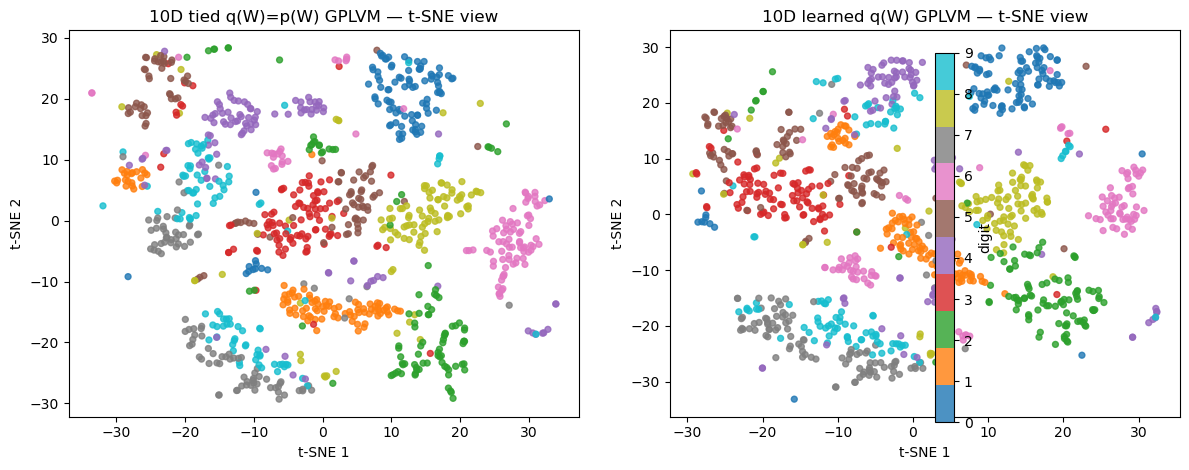

In [113]:
z_tied_w = latent_means(tied_w_model, images)
z_learned_qw = latent_means(learned_qw_model, images)
z_tied_w_tsne = tsne_projection(z_tied_w[visualization_indices], steps=500, seed=SEED)
z_learned_qw_tsne = tsne_projection(z_learned_qw[visualization_indices], steps=500, seed=SEED)
for name, z in [("tied q(W)=p(W)", z_tied_w), ("learned Gaussian q(W)", z_learned_qw)]:
    values = embedding_metrics(z, labels)
    print(name, {key: round(value, 3) for key, value in values.items()})

tied_elbo = -np.mean(tied_w_history.loss[-5:])
learned_elbo = -np.mean(learned_qw_history.loss[-5:])
print(f"mean final ELBO/pixel — q(W)=p(W): {tied_elbo:.5f}")
print(f"mean final ELBO/pixel — learned q(W): {learned_elbo:.5f}")
print(f"ELBO difference (learned − tied): {learned_elbo - tied_elbo:+.5f}")
print("q(W) summary:", learned_qw_model.spectral_prior.summary())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_embedding(z_tied_w_tsne, labels[visualization_indices], "10D tied q(W)=p(W) GPLVM — t-SNE view", axes[0])
plot_embedding(z_learned_qw_tsne, labels[visualization_indices], "10D learned q(W) GPLVM — t-SNE view", axes[1])
fig.colorbar(axes[1].collections[0], ax=axes, ticks=range(10), label="digit")
plt.tight_layout()

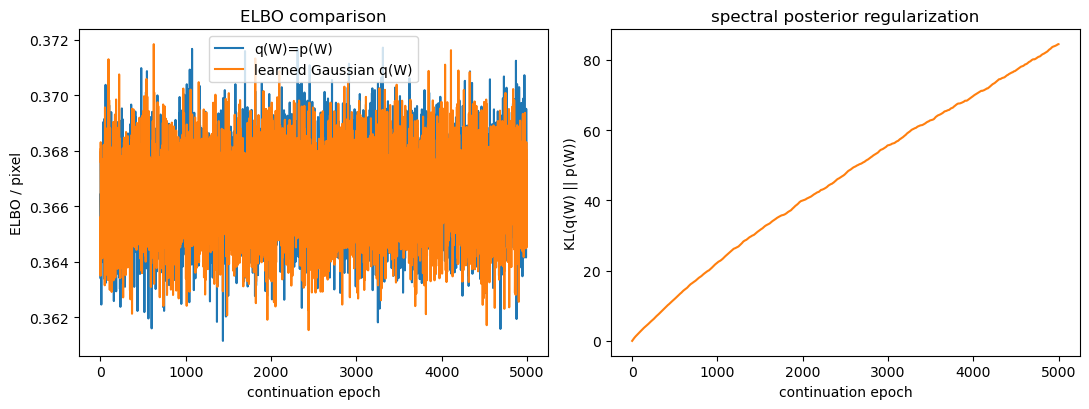

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(-np.asarray(tied_w_history.loss), label="q(W)=p(W)")
axes[0].plot(-np.asarray(learned_qw_history.loss), label="learned Gaussian q(W)")
axes[0].set(title="ELBO comparison", xlabel="continuation epoch", ylabel="ELBO / pixel")
axes[0].legend()
axes[1].plot(learned_qw_history.kl_w, color="tab:orange")
axes[1].set(title="spectral posterior regularization", xlabel="continuation epoch", ylabel="KL(q(W) || p(W))")
plt.tight_layout()

The learned posterior is more expressive because individual spectral points may move and
change uncertainty in response to MNIST. This does not guarantee improvement on every seed: it
adds $2LQ=4{,}000$ variational parameters and can overfit. The objective comparison is meaningful
only when the spectral KL is included, as above; comparing reconstruction terms alone would
unfairly favor the learned posterior.